# DenseNet matched-image representation geometry and local label entropy

Models: DenseNet-121 / DenseNet-169 / DenseNet-201, explicit torchvision ImageNet-1K V1 weights. This adds a densely connected CNN family to the existing ResNet, ConvNeXt, ViT and Swin experiments.

## Controlled variables
- Same Zenodo cats_dogs_light.zip (MD5 verified), ZIP member order, NumPy default_rng(42) selection: 100 cats + 100 dogs in the same shuffled order as the maintained CNN protocol.
- Shared ResNet-18 V1 resize/crop/normalization. Frozen evaluation mode, float32 inference, batch size 8, no augmentation or fine-tuning.
- Same growth rate 32 and bottleneck multiplier 4; model block counts, resulting widths, parameter counts and independently trained checkpoints differ.
- Stem, complete cumulative concatenated state after every dense layer, each transition, and explicit final norm+ReLU. Spatial global mean pooling. Observations: 63 / 87 / 103.
- S, within/between cosine and unit Euclidean distances, raw Fisher ratio, mean raw norm, centered-unit participation ratio, adjacent raw linear CKA.
- Linear probes: five shared stratified 70/30 splits, seed 42, unit normalization, training-only standardization, LogisticRegression C=1 / liblinear.
- LLE: cosine kNN, query excluded, stable tie handling; k=4,8,16,32,64; 100 shared shuffled-label assignments using seed 1042.

## Outputs and checks
Geometry and LLE summary CSVs, per-image LLE CSVs, sample manifest, probe split identities, explicit weight/device/version protocol, per-image vector NPZs and SHA-256 artifact manifest. Runtime assertions verify full cumulative-state pooling against every actual dense-block output and identical label order for all model passes.

The first code cell writes self-contained reproducible scripts and runs all three models sequentially. Large activations, dataset and weights stay outside Git. CSVs and the executed notebook are published separately from the historical runs.

## Interpretation limits
This is an exploratory within-family comparison, not a causal depth-only intervention: widths, independently trained checkpoints and block allocation also differ. Cumulative channel retention itself affects adjacent CKA and geometry. Final norm+ReLU is a readout transformation, not an additional dense layer. Observation indices do not represent equal computational depth. Increasing S does not prove absolute contraction; decreasing LLE need not be monotonic or imply thermodynamic self-organization. No held-out boundary diagnostic is performed in this run.

Reference: https://docs.pytorch.org/vision/stable/_modules/torchvision/models/densenet.html


In [1]:
from pathlib import Path
import os, subprocess, sys
os.environ['GEOMETRY_OUTPUT_DIR']='/content/densenet_outputs'
Path('/content/metrics.py').write_text('"""Geometry definitions from the CNN experiment; labels 3=cat, 5=dog."""\nimport numpy as np\n# Metrics: cosine pairwise geometry on per-image unit vectors; raw Fisher ratio.\n# Squared Euclidean distance on unit vectors is 2 * cosine distance, so these are not independent measurements.\ndef representation_stats(x,y):\n    x=np.asarray(x,dtype=np.float64)\n    z=x/np.maximum(np.linalg.norm(x,axis=1,keepdims=True),1e-12)\n    cat,dog=z[y==3],z[y==5]\n    def within_cos(q):\n        n=len(q)\n        return 1-(np.sum(q.sum(axis=0)**2)-n)/(n*(n-1))\n    dc=(within_cos(cat)+within_cos(dog))/2\n    db=1-cat.mean(axis=0)@dog.mean(axis=0)\n    # For mean *Euclidean* pairwise distances, use a 200x200 distance matrix.\n    sim=np.clip(z@z.T,-1,1)\n    dist=np.sqrt(np.maximum(0,2-2*sim))\n    ci=np.flatnonzero(y==3); di=np.flatnonzero(y==5)\n    wc=dist[np.ix_(ci,ci)][np.triu_indices(len(ci),1)].mean()\n    wd=dist[np.ix_(di,di)][np.triu_indices(len(di),1)].mean()\n    edw=(wc+wd)/2; edb=dist[np.ix_(ci,di)].mean()\n    # Fisher on raw, globally pooled features, invariant to a global scalar only.\n    a,b=x[y==3],x[y==5]; ma,mb=a.mean(0),b.mean(0)\n    var=np.mean(np.sum((a-ma)**2,axis=1))+np.mean(np.sum((b-mb)**2,axis=1))\n    fisher=np.sum((ma-mb)**2)/max(var,1e-20)\n    centered=z-z.mean(0)\n    eigen=np.maximum(np.linalg.eigvalsh(centered@centered.T),0)\n    pr=eigen.sum()**2/max(np.square(eigen).sum(),1e-20)\n    return {\'d_within_cos\':dc,\'d_between_cos\':db,\'S\':db/dc,\n            \'d_within_euclid_unit\':edw,\'d_between_euclid_unit\':edb,\n            \'Fisher_raw\':fisher,\'PR\':pr,\'mean_raw_norm\':np.linalg.norm(x,axis=1).mean()}\n\ndef centered_gram(x):\n    x=np.asarray(x,dtype=np.float64)\n    x=x-x.mean(0,keepdims=True)\n    gram=x@x.T\n    return gram/np.maximum(np.linalg.norm(gram,\'fro\'),1e-20)\n\ndef linear_cka(x1,x2):\n    return float(np.sum(centered_gram(x1)*centered_gram(x2)))\n\n')
Path('/content/run_densenet_geometry.py').write_text('"""Matched DenseNet-121/169/201 geometry and LLE; run in Colab or Python.\n\nDense-layer observations pool the full cumulative concatenated state, not\nonly the 32 newly produced channels. Transitions and final norm+ReLU are\nexplicit observations. Checkpoints differ, so this is not a depth-only test.\n"""\nimport os\nfrom pathlib import Path\nimport gc, hashlib, json, time, zipfile, urllib.request, platform\nfrom io import BytesIO\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torchvision\nfrom torchvision import models\nfrom torch.utils.data import Dataset, DataLoader\nfrom PIL import Image\nfrom scipy.stats import entropy\nfrom sklearn.metrics.pairwise import cosine_distances\nfrom sklearn.model_selection import StratifiedShuffleSplit\nfrom sklearn.pipeline import make_pipeline\nfrom sklearn.preprocessing import Normalizer, StandardScaler\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.metrics import accuracy_score\nimport sklearn, scipy\nfrom metrics import representation_stats, centered_gram\n\nSEED=42\nKS=(4,8,16,32,64)\nROOT=Path(os.environ.get(\'GEOMETRY_OUTPUT_DIR\',\'outputs/densenet\')).resolve()\nSPECS=((\'DenseNet-121\',models.densenet121,models.DenseNet121_Weights.IMAGENET1K_V1,(6,12,24,16)),\n       (\'DenseNet-169\',models.densenet169,models.DenseNet169_Weights.IMAGENET1K_V1,(6,12,32,32)),\n       (\'DenseNet-201\',models.densenet201,models.DenseNet201_Weights.IMAGENET1K_V1,(6,12,48,32)))\n\n\ndef cohort():\n    ROOT.mkdir(parents=True,exist_ok=True)\n    archive=ROOT/\'cats_dogs_light.zip\'\n    if not archive.exists():\n        urllib.request.urlretrieve(\'https://zenodo.org/records/5226945/files/cats_dogs_light.zip?download=1\',archive)\n    assert hashlib.md5(archive.read_bytes()).hexdigest()==\'5e014163374c3bf7069c923de2d619c8\'\n    with zipfile.ZipFile(archive) as z:\n        names=[n for n in z.namelist() if \'/test/\' in n.lower()\n               and n.lower().endswith((\'.jpg\',\'.jpeg\',\'.png\'))\n               and Path(n).name.lower().startswith((\'cat.\',\'dog.\'))]\n    targets=np.array([3 if Path(n).name.lower().startswith(\'cat.\') else 5 for n in names])\n    rng=np.random.default_rng(SEED)\n    indices=np.concatenate([rng.choice(np.flatnonzero(targets==c),100,replace=False) for c in (3,5)])\n    indices=rng.permutation(indices)\n    labels=targets[indices]; paths=[names[i] for i in indices]\n    assert len(set(paths))==200 and np.array_equal(np.unique(labels,return_counts=True)[1],[100,100])\n    transform=models.ResNet18_Weights.IMAGENET1K_V1.transforms()\n    class Images(Dataset):\n        def __len__(self): return len(paths)\n        def __getitem__(self,i):\n            with zipfile.ZipFile(archive) as z:\n                image=Image.open(BytesIO(z.read(paths[i]))).convert(\'RGB\')\n            return transform(image), int(labels[i])\n    manifest=pd.DataFrame(dict(sample_index=np.arange(200),selected_index=indices,image_path=paths,label=labels))\n    manifest.to_csv(ROOT/\'sample_manifest.csv\',index=False)\n    return Images(),labels,paths,indices,str(transform)\n\n\ndef extract(net,loader,device,config):\n    """Read cumulative states without modifying model activations.\n\n    GAP commutes with channel concatenation. At each dense block entry capture\n    its input GAP; append GAP of each dense layer\'s newly produced channels.\n    Verify the last cumulative state against actual dense-block output GAP.\n    """\n    stages=[\'stem\']; boundaries={\'stem\'}\n    for s,count in enumerate(config,1):\n        for j in range(count):\n            key=f\'s{s}.d{j+1}\'; stages.append(key)\n            if j==0: boundaries.add(key)\n        if s<4: stages.append(f\'down{s}\'); boundaries.add(f\'down{s}\')\n    stages.append(\'final_norm_relu\')\n    record={k:[] for k in stages}; cache={}; cumulative={}; handles=[]\n    def pooled(out): return out.detach().float().mean((-2,-1)).cpu().numpy()\n    def simple(key,relu=False):\n        def capture(_m,_inp,out): cache[key]=pooled(torch.relu(out) if relu else out)\n        return capture\n    handles.append(net.features.pool0.register_forward_hook(simple(\'stem\')))\n    for s,count in enumerate(config,1):\n        block=getattr(net.features,f\'denseblock{s}\')\n        assert len(block)==count\n        def begin(_m,inp,s=s): cumulative[s]=pooled(inp[0])\n        handles.append(block.register_forward_pre_hook(begin))\n        for j,layer in enumerate(block):\n            key=f\'s{s}.d{j+1}\'\n            def capture(_m,_inp,out,s=s,key=key):\n                cumulative[s]=np.concatenate([cumulative[s],pooled(out)],axis=1)\n                cache[key]=cumulative[s]\n            handles.append(block[layer].register_forward_hook(capture))\n        def check(_m,_inp,out,s=s,count=count):\n            np.testing.assert_allclose(cache[f\'s{s}.d{count}\'],pooled(out),rtol=1e-5,atol=1e-6)\n        handles.append(block.register_forward_hook(check))\n        if s<4: handles.append(getattr(net.features,f\'transition{s}\').register_forward_hook(simple(f\'down{s}\')))\n    handles.append(net.features.norm5.register_forward_hook(simple(\'final_norm_relu\',True)))\n    start=time.time(); seen=[]\n    try:\n        net.to(device).eval()\n        for p in net.parameters(): p.requires_grad_(False)\n        with torch.inference_mode():\n            for i,(images,y) in enumerate(loader):\n                cache.clear(); cumulative.clear(); net(images.to(device))\n                assert list(cache)==stages\n                for key in stages: record[key].append(cache[key])\n                seen.extend(y.numpy().tolist())\n                if (i+1)%5==0 or i+1==len(loader): print(f\'  batch {i+1}/{len(loader)} {time.time()-start:.1f}s\',flush=True)\n    finally:\n        for h in handles: h.remove()\n        net.cpu(); torch.cuda.empty_cache()\n    feats={k:np.concatenate(v) for k,v in record.items()}\n    return feats,boundaries,np.array(seen)\n\n\ndef point_entropy(nn,y,k):\n    p=(y[nn[:,:k]]==5).mean(1)\n    return entropy(np.stack([1-p,p],axis=1),base=2,axis=1)\n\n\ndef analyze(feats,name,labels,paths,boundaries,splits,shuffled):\n    rows=[]; lle=[]; points=[]; previous=None\n    for depth,(stage,x) in enumerate(feats.items()):\n        assert x.shape[0]==200 and x.ndim==2 and np.isfinite(x).all()\n        assert np.all(np.linalg.norm(x,axis=1)>1e-12)\n        gram=centered_gram(x)\n        scores=[]\n        for train,test in splits:\n            p=make_pipeline(Normalizer(),StandardScaler(),LogisticRegression(C=1,max_iter=2000,solver=\'liblinear\',random_state=SEED))\n            p.fit(x[train],labels[train]); scores.append(accuracy_score(labels[test],p.predict(x[test])))\n        rows.append(dict(model=name,depth=depth,stage=stage,boundary=stage in boundaries,\n                         readout_kind=\'final_norm_relu\' if stage==\'final_norm_relu\' else (\'transition\' if stage.startswith(\'down\') else \'cumulative_state\'),\n                         feature_width=x.shape[1],CKA_prev=np.nan if previous is None else float(np.sum(previous*gram)),\n                         probe_mean=float(np.mean(scores)),probe_sd=float(np.std(scores,ddof=1)),**representation_stats(x,labels)))\n        previous=gram\n        d=cosine_distances(x); np.fill_diagonal(d,np.inf)\n        nn=np.argsort(d,axis=1,kind=\'stable\')[:,:max(KS)]\n        assert not np.any(nn==np.arange(200)[:,None])\n        for k in KS:\n            h=point_entropy(nn,labels,k)\n            null=np.array([point_entropy(nn,y,k).mean() for y in shuffled])\n            lle.append(dict(model=name,depth=depth,stage=stage,k=k,LLE=float(h.mean()),shuffle_mean=float(null.mean()),shuffle_sd=float(null.std(ddof=1)),order_vs_shuffle=float(1-h.mean()/null.mean()),fraction_H_ge_0_8=float((h>=.8).mean())))\n            points.extend(dict(model=name,depth=depth,stage=stage,k=k,sample_index=i,image_path=paths[i],label=int(labels[i]),H=float(h[i])) for i in range(200))\n        if depth%10==0: print(f\'  measured {depth+1}/{len(feats)} observations\',flush=True)\n    df=pd.DataFrame(rows)\n    for field in (\'S\',\'Fisher_raw\',\'PR\',\'probe_mean\'): df[\'delta_\'+field]=df[field].diff()\n    return df,pd.DataFrame(lle),pd.DataFrame(points)\n\n\ndef main():\n    torch.manual_seed(SEED); np.random.seed(SEED); torch.set_num_threads(2)\n    torch.backends.cudnn.benchmark=False; torch.backends.cudnn.deterministic=True\n    torch.backends.cuda.matmul.allow_tf32=False; torch.backends.cudnn.allow_tf32=False\n    device=torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\n    data,labels,paths,indices,transform=cohort()\n    loader=DataLoader(data,batch_size=8,shuffle=False,num_workers=0)\n    splits=list(StratifiedShuffleSplit(n_splits=5,test_size=.30,random_state=SEED).split(np.zeros(200),labels))\n    null_rng=np.random.default_rng(SEED+1000)\n    shuffled=np.stack([null_rng.permutation(labels) for _ in range(100)])\n    split_rows=[dict(split=s,sample_index=int(i),role=role) for s,(tr,te) in enumerate(splits) for role,idx in [(\'train\',tr),(\'test\',te)] for i in idx]\n    pd.DataFrame(split_rows).to_csv(ROOT/\'probe_splits.csv\',index=False)\n    metadata=dict(status=\'running\',seed=SEED,batch_size=8,cohort_size=200,archive_md5=\'5e014163374c3bf7069c923de2d619c8\',\n                  preprocessing=transform,k_values=KS,n_shuffles=100,shuffle_seed=SEED+1000,probe=\'5 paired stratified 70/30 splits; Normalizer+train-only StandardScaler+LogisticRegression(C=1,liblinear)\',\n                  precision=\'float32 inference; float64 geometry; sklearn cosine_distances float32 LLE\',\n                  device=str(device),gpu=torch.cuda.get_device_name() if device.type==\'cuda\' else None,\n                  python=platform.python_version(),torch=torch.__version__,torchvision=torchvision.__version__,numpy=np.__version__,pandas=pd.__version__,scipy=scipy.__version__,sklearn=sklearn.__version__,\n                  pooling=\'spatial mean of cumulative concatenated dense state; final norm+ReLU separately observed\',\n                  cautions=\'Model depth, width and independently trained checkpoints vary; not a causal depth-only comparison. No boundary diagnostic in this run.\',models=[])\n    (ROOT/\'protocol.json\').write_text(json.dumps(metadata,indent=2))\n    all_geo=[]; all_lle=[]; endpoints=[]\n    print(\'Matched 100 cats + 100 dogs;\',device,metadata[\'gpu\'],flush=True)\n    for name,constructor,weights,config in SPECS:\n        started=time.time(); print(\'Starting\',name,str(weights),flush=True)\n        net=constructor(weights=weights)\n        count=sum(p.numel() for p in net.parameters())\n        feats,boundaries,seen=extract(net,loader,device,config)\n        assert np.array_equal(seen,labels)\n        assert len(feats)==sum(config)+5\n        del net; gc.collect()\n        slug=name.lower().replace(\'-\',\'\')\n        payload=dict(stages=np.array(list(feats)),labels=labels,archive_paths=np.array(paths),selected_indices=indices,weights=np.array(str(weights)))\n        payload.update({f\'features_{i}\':x for i,x in enumerate(feats.values())})\n        np.savez_compressed(ROOT/f\'{slug}_per_image_vectors.npz\',**payload)\n        df,l,p=analyze(feats,name,labels,paths,boundaries,splits,shuffled)\n        df.to_csv(ROOT/f\'{slug}_geometry.csv\',index=False); l.to_csv(ROOT/f\'{slug}_lle_summary.csv\',index=False)\n        p.to_csv(ROOT/f\'{slug}_lle_per_image.csv\',index=False)\n        all_geo.append(df); all_lle.append(l)\n        q=l[l.k==16]; dip=df.loc[df.CKA_prev.idxmin()]\n        endpoints.append(dict(model=name,observations=len(df),S_first=df.S.iloc[0],S_last=df.S.iloc[-1],within_first=df.d_within_cos.iloc[0],within_last=df.d_within_cos.iloc[-1],LLE_k16_first=q.LLE.iloc[0],LLE_k16_last=q.LLE.iloc[-1],LLE_k16_increasing_transitions=int((q.LLE.diff()>0).sum()),probe_first=df.probe_mean.iloc[0],probe_last=df.probe_mean.iloc[-1],min_CKA=dip.CKA_prev,min_CKA_at=dip.stage))\n        metadata[\'models\'].append(dict(model=name,weights=str(weights),checkpoint_url=weights.url,parameters=count,block_config=config,growth_rate=32,bn_size=4,observations=len(df),seconds=time.time()-started,stages=list(feats),widths=[x.shape[1] for x in feats.values()]))\n        (ROOT/\'protocol.json\').write_text(json.dumps(metadata,indent=2))\n        print(\'Finished\',name,len(df),\'observations\',flush=True)\n        del feats,p,payload; gc.collect()\n    g=pd.concat(all_geo,ignore_index=True); l=pd.concat(all_lle,ignore_index=True)\n    g.to_csv(ROOT/\'densenet_geometry_metrics.csv\',index=False); l.to_csv(ROOT/\'densenet_lle_summary.csv\',index=False)\n    pd.DataFrame(endpoints).to_csv(ROOT/\'densenet_endpoint_summary.csv\',index=False)\n    assert len(g)==253 and len(l)==1265\n    import matplotlib\n    matplotlib.use(\'Agg\')\n    import matplotlib.pyplot as plt\n    fig,axs=plt.subplots(3,2,figsize=(14,11),constrained_layout=True)\n    for ax,(field,title) in zip(axs.flat,[(\'S\',\'Relative separation S\'),(\'CKA_prev\',\'Adjacent raw linear CKA\'),(\'d_within_cos\',\'Within cosine distance\'),(\'d_between_cos\',\'Between cosine distance\'),(\'PR\',\'Participation ratio\'),(\'probe_mean\',\'Held-out probe accuracy\')]):\n        for name,q in g.groupby(\'model\',sort=False): ax.plot(q.depth,q[field],label=name)\n        ax.set(title=title,xlabel=\'Observation index\'); ax.legend(fontsize=8)\n    fig.savefig(ROOT/\'densenet_geometry.png\',dpi=140); plt.close(fig)\n    fig,axs=plt.subplots(1,3,figsize=(16,4),constrained_layout=True)\n    for ax,(name,q) in zip(axs,l.groupby(\'model\',sort=False)):\n        for k,v in q.groupby(\'k\'): ax.plot(v.depth,v.LLE,label=f\'k={k}\')\n        ax.set(title=name,xlabel=\'Observation index\',ylabel=\'Mean local label entropy (bits)\',ylim=(0,1));ax.legend(fontsize=8)\n    fig.savefig(ROOT/\'densenet_lle.png\',dpi=140);plt.close(fig)\n    metadata[\'status\']=\'completed\'; metadata[\'completed_utc\']=__import__(\'datetime\').datetime.now(__import__(\'datetime\').timezone.utc).isoformat()\n    (ROOT/\'protocol.json\').write_text(json.dumps(metadata,indent=2))\n    files={p.name:dict(sha256=hashlib.sha256(p.read_bytes()).hexdigest(),bytes=p.stat().st_size) for p in ROOT.iterdir() if p.suffix in (\'.csv\',\'.json\',\'.png\',\'.npz\') and p.name!=\'artifact_manifest.json\'}\n    (ROOT/\'artifact_manifest.json\').write_text(json.dumps(files,indent=2))\n    print(pd.DataFrame(endpoints).to_string(index=False),flush=True)\n    print(\'COMPLETED: 253 geometry rows, 1265 LLE summary rows, 253000 per-image LLE rows.\',flush=True)\n\nif __name__==\'__main__\': main()\n')
subprocess.run([sys.executable, '-u', '/content/run_densenet_geometry.py'], check=True)


CompletedProcess(args=['/usr/bin/python3', '-u', '/content/run_densenet_geometry.py'], returncode=0)

COMPLETED: cuda Tesla T4 2026-09-30T22:23:16.424458+00:00
torch: 2.11.0+cu128 torchvision: 0.26.0+cu128


,model,observations,S_first,S_last,within_first,within_last,LLE_k16_first,LLE_k16_last,LLE_k16_increasing_transitions,probe_first,probe_last,min_CKA,min_CKA_at
0,DenseNet-121,63,1.04402,1.30454,0.04565,0.36084,0.93754,0.11375,12,0.62000,0.99667,0.44403,down1
1,DenseNet-169,87,1.07126,1.25984,0.03863,0.40237,0.93856,0.07969,19,0.59000,1.00000,0.51548,down2
2,DenseNet-201,103,1.02635,1.27966,0.03105,0.42258,0.94445,0.07758,26,0.63333,1.00000,0.42935,down1


Geometry rows: 253
LLE summary rows: 1265
All result hashes and expected row counts verified.


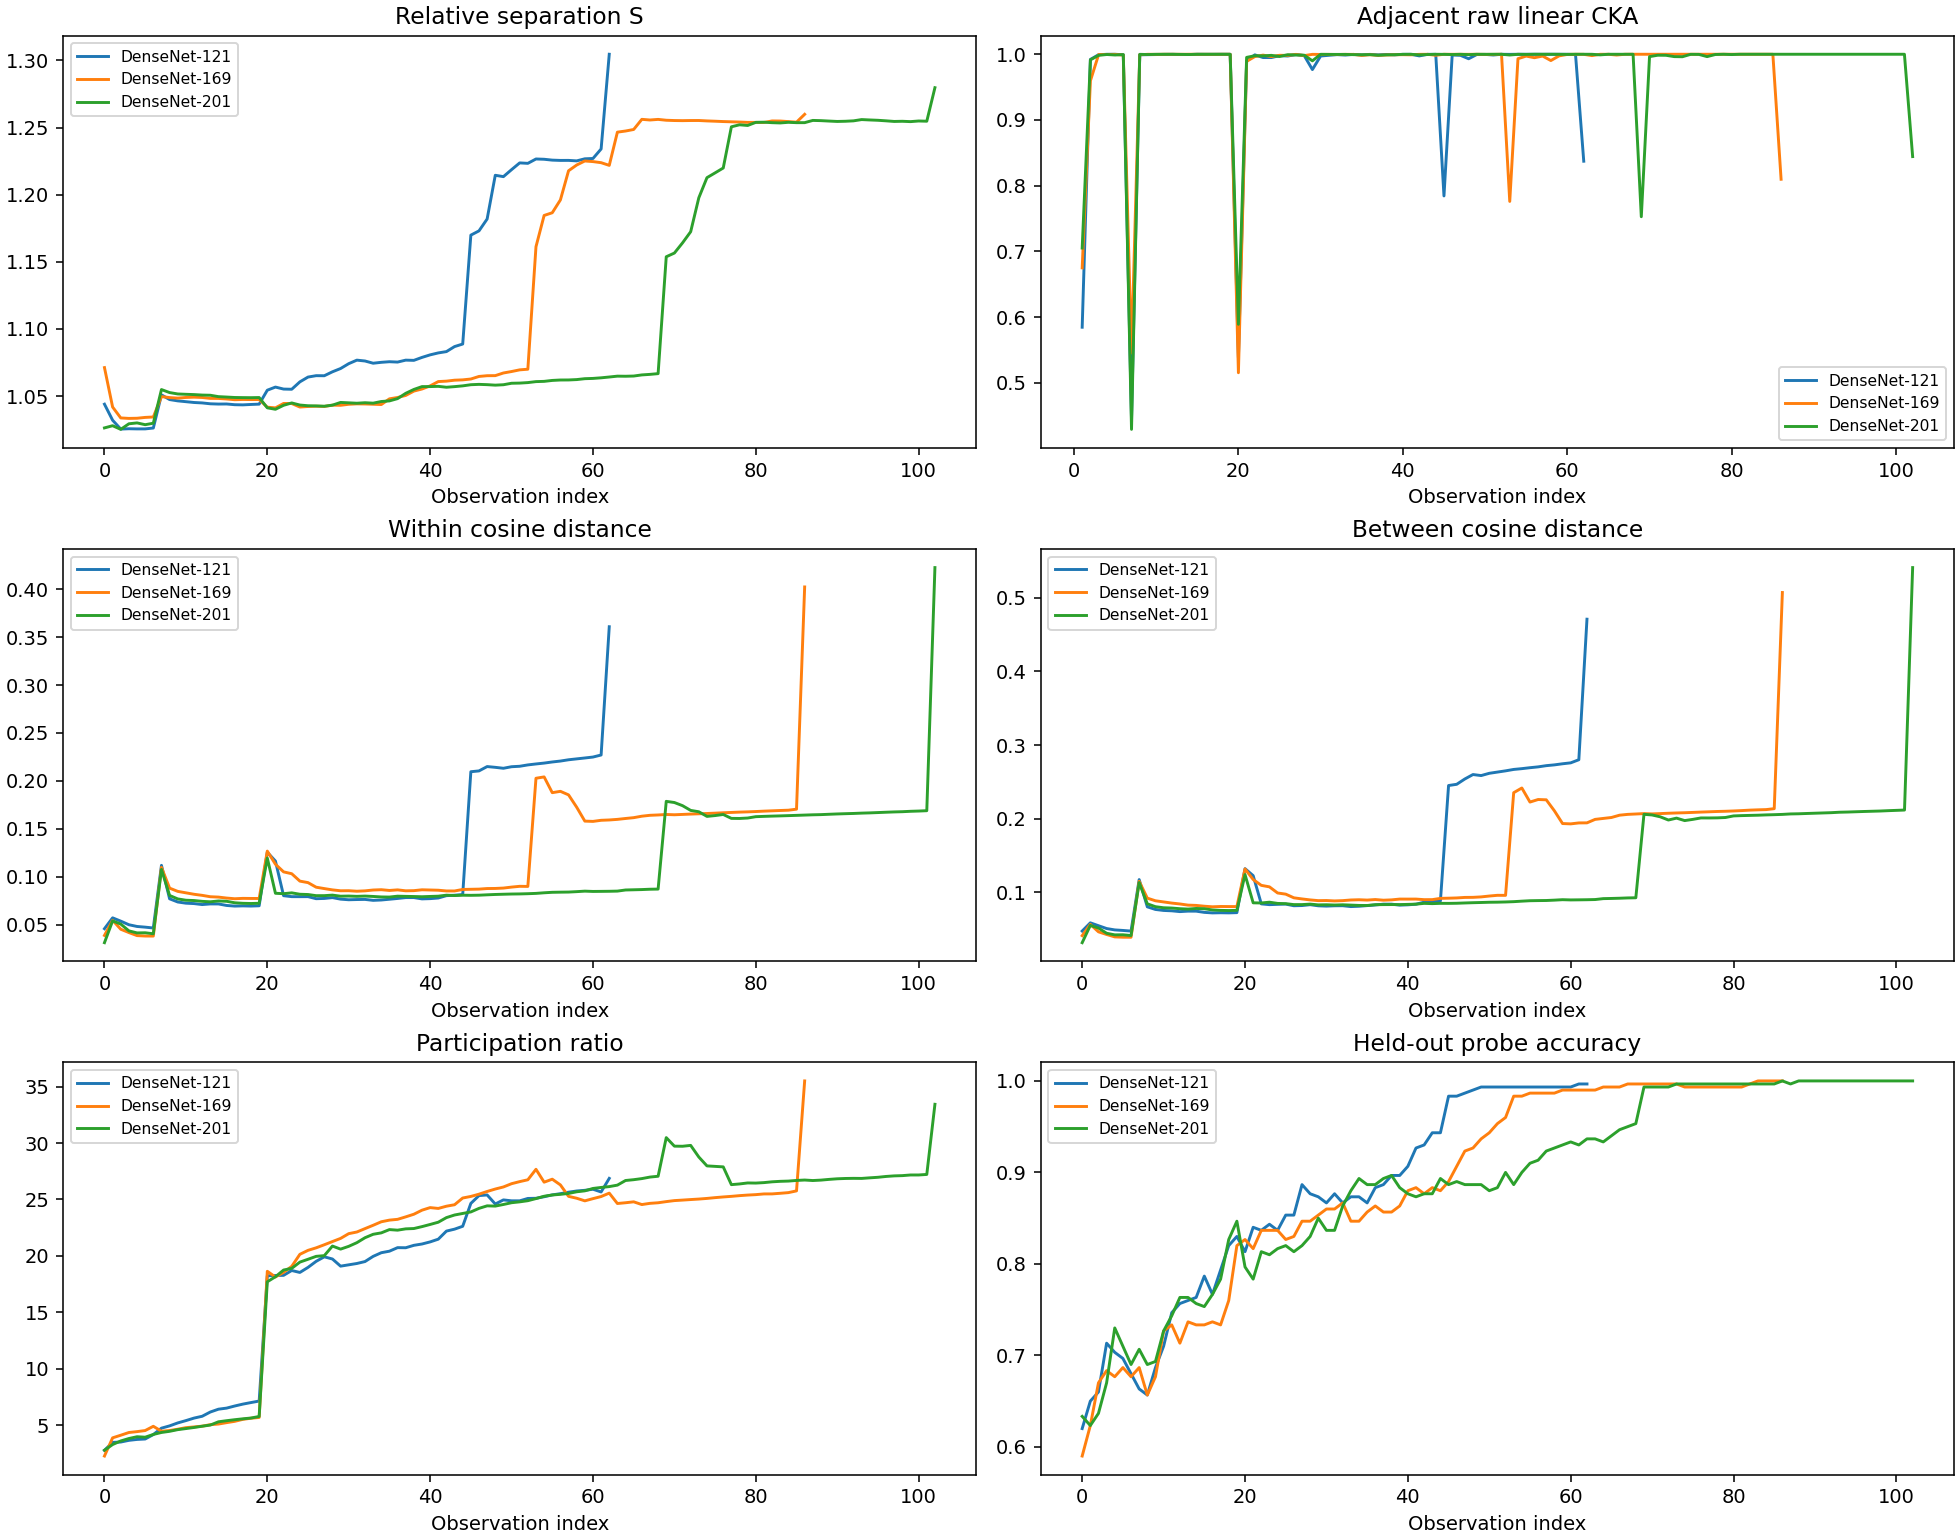

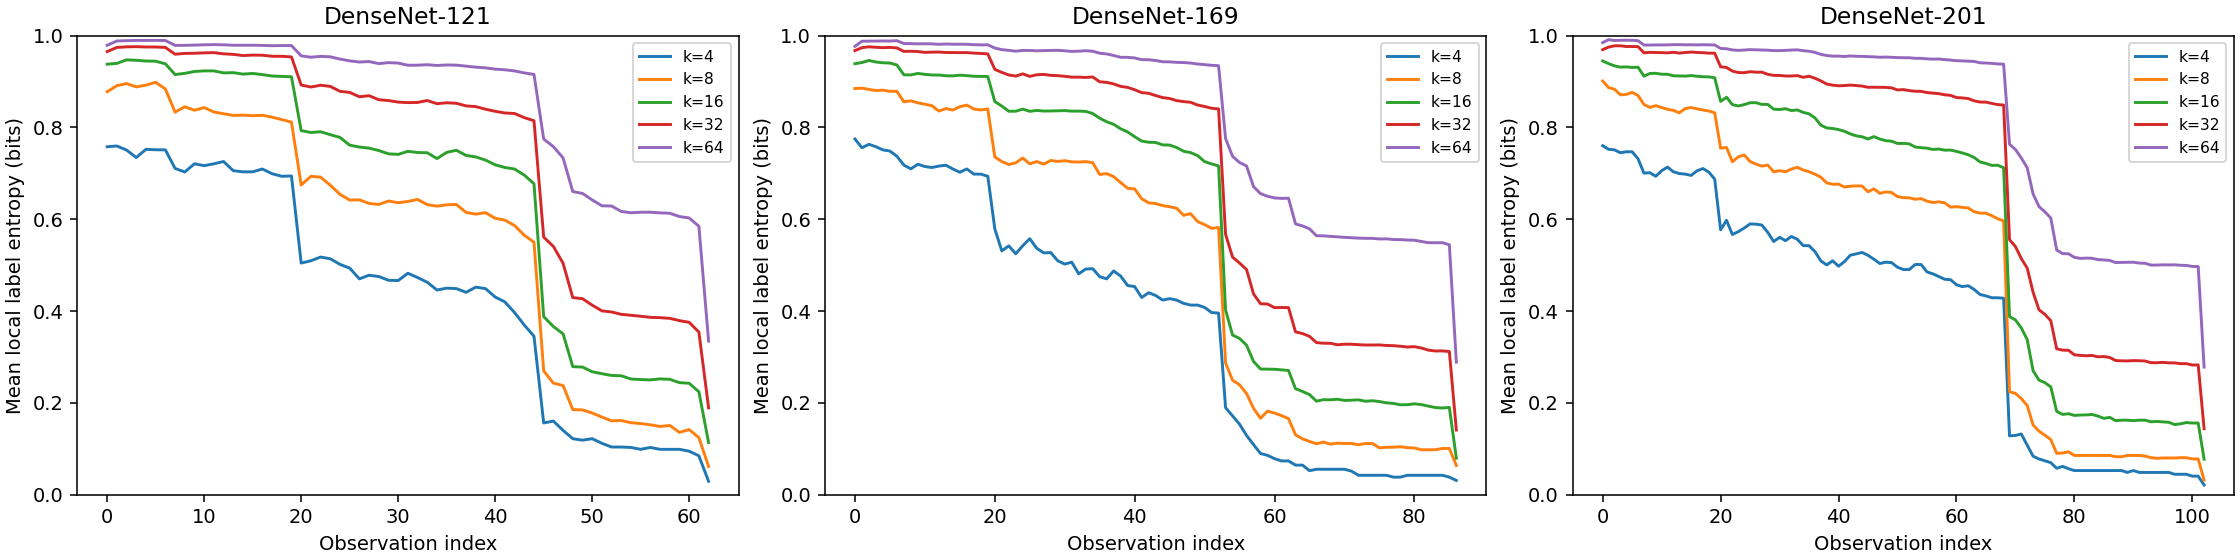

In [2]:
from pathlib import Path
import json, hashlib
import pandas as pd
from IPython.display import display, Image
root = Path('/content/densenet_outputs')
protocol = json.loads((root/'protocol.json').read_text())
assert protocol['status'] == 'completed'
print('COMPLETED:', protocol['device'], protocol['gpu'], protocol['completed_utc'])
print('torch:', protocol['torch'], 'torchvision:', protocol['torchvision'])
display(pd.read_csv(root/'densenet_endpoint_summary.csv').round(5))
print('Geometry rows:', len(pd.read_csv(root/'densenet_geometry_metrics.csv')))
print('LLE summary rows:', len(pd.read_csv(root/'densenet_lle_summary.csv')))
for slug, count in [('densenet121',63000),('densenet169',87000),('densenet201',103000)]:
    assert len(pd.read_csv(root/f'{slug}_lle_per_image.csv')) == count
manifest = json.loads((root/'artifact_manifest.json').read_text())
for name, info in manifest.items():
    assert hashlib.sha256((root/name).read_bytes()).hexdigest() == info['sha256'], name
print('All result hashes and expected row counts verified.')
display(Image(filename=str(root/'densenet_geometry.png')))
display(Image(filename=str(root/'densenet_lle.png')))


In [3]:
# Export measured CSVs and provenance; exclude dataset, checkpoints and activations.
from pathlib import Path
import zipfile
from google.colab import files
root=Path('/content/densenet_outputs')
with zipfile.ZipFile('/content/densenet_results_20260930.zip','w',zipfile.ZIP_DEFLATED) as z:
    for p in sorted(root.iterdir()):
        if p.suffix in ('.csv','.json','.png'): z.write(p,p.name)
    z.write('/content/run_densenet_geometry.py','run_densenet_geometry.py')
    z.write('/content/metrics.py','metrics.py')
files.download('/content/densenet_results_20260930.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>